## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [1]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [144]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


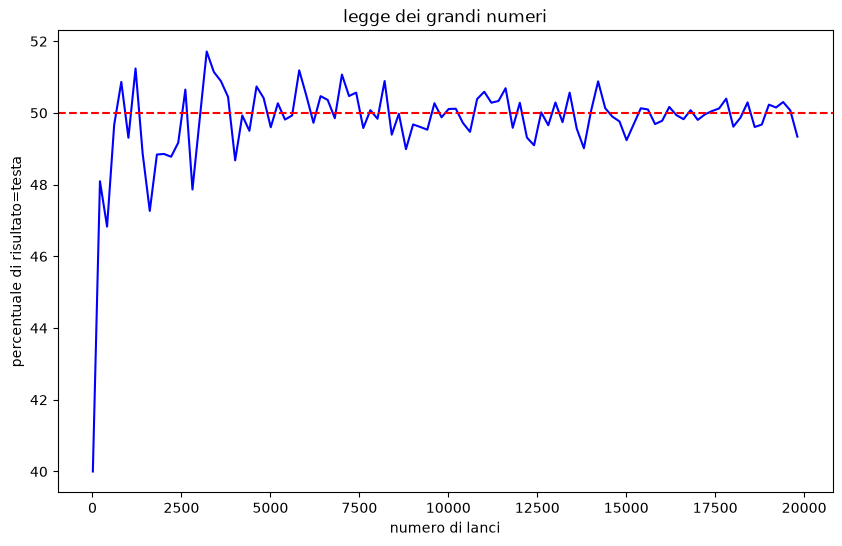

In [145]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [76]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


In [77]:
# Controllo righe e colonne
print('Il numero di righe è:', len(df))
print('\nIl numero di colonne è:', len(df.columns))

#Valori macanti per colonna
print('\nValori mancanti per colonna:\n',df.isna().sum()) 

Il numero di righe è: 891

Il numero di colonne è: 12

Valori mancanti per colonna:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Uso il valore più frequente di embarked per sostituirlo con i Nan
print('\nTabella frequenze assolute di Emarked:\n',df.Embarked.value_counts(dropna=False))
#Ora sostituisco i NaN con 'S'
df.Embarked = df.Embarked.fillna('S')

#Controllo la presenza di righe duplicate
print('\nNumero righe duplicate:',df.duplicated().sum())

#Controllo l'età media per classe e la sostituisco nei valori mancanti
eta_media_pc = df.groupby('Pclass')['Age'].mean().astype(int)
print('\nEtà media per classe:\n',eta_media_pc)
df.Age = df.Age.fillna(df.Pclass.map(eta_media_pc))



Tabella frequenze assolute di Emarked:
 Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Numero righe duplicate: 0

Età media per classe:
 Pclass
1    38
2    29
3    25
Name: Age, dtype: int64


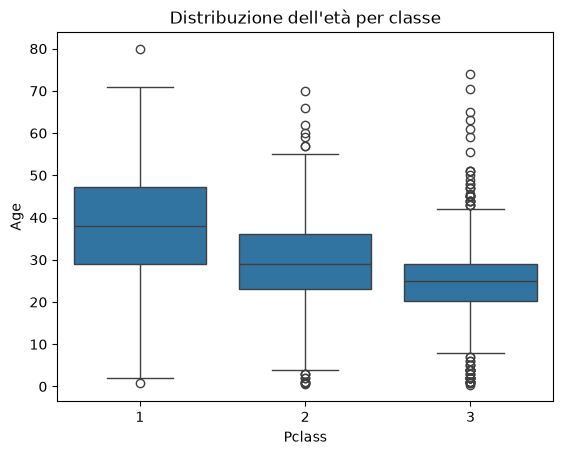

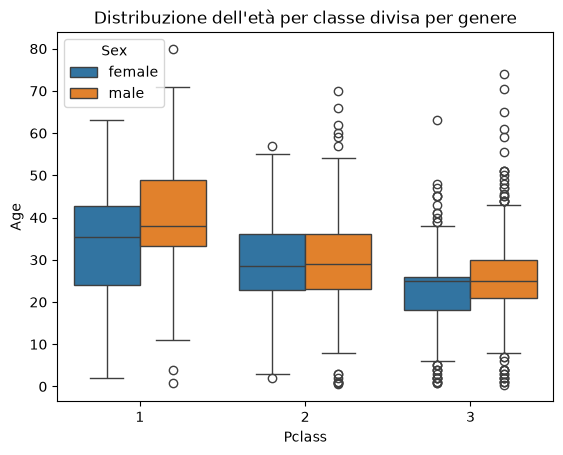

In [87]:
#Distribuzione di età per classe 
sns.boxplot(data=df,y='Age',x='Pclass')
plt.title('Distribuzione dell\'età per classe')
plt.show()

#Distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne
sns.boxplot(data=df,y='Age',x='Pclass',hue='Sex')
plt.title('Distribuzione dell\'età per classe divisa per genere')
plt.show()


## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
#Distribuzione per specie
print('Distribuzione per specie:\n', df.species.value_counts(dropna=False))

#Lunghezza e larghezza media petalo per specie
print('\nLarghezza e lunghezza media petalo per specie:\n',df.groupby('species')[['petal_length', 'petal_width']].mean())

Distribuzione per specie:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Larghezza e lunghezza media petalo per specie:
             petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


<function matplotlib.pyplot.show(close=None, block=None)>

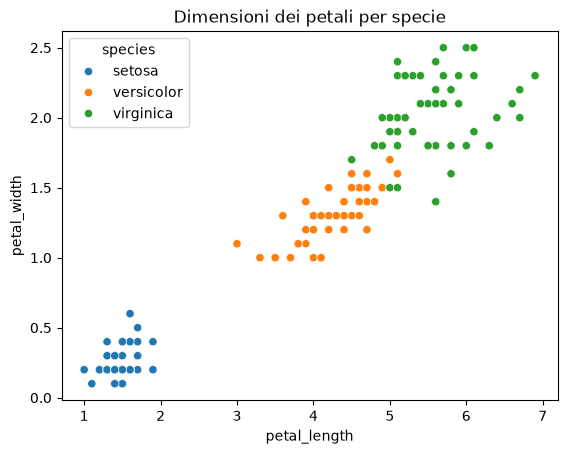

In [108]:
#Dimensioni dei petali per specie (scatterplot)
sns.scatterplot(x=df.petal_length, y=df.petal_width, hue = df.species)
plt.title('Dimensioni dei petali per specie')
plt.show

In [122]:
#Nuova colonna per l'area del petalo
df['petal_area'] = df['petal_length']*df['petal_width']
#Esplorazione
print(df.groupby('species')['petal_area'].describe())

            count     mean       std   min     25%     50%    75%    max
species                                                                 
setosa       50.0   0.3656  0.181155  0.11  0.2800   0.300   0.42   0.96
versicolor   50.0   5.7204  1.368403  3.30  4.8600   5.615   6.75   8.64
virginica    50.0  11.2962  2.157412  7.50  9.7175  11.445  12.79  15.87


<function matplotlib.pyplot.show(close=None, block=None)>

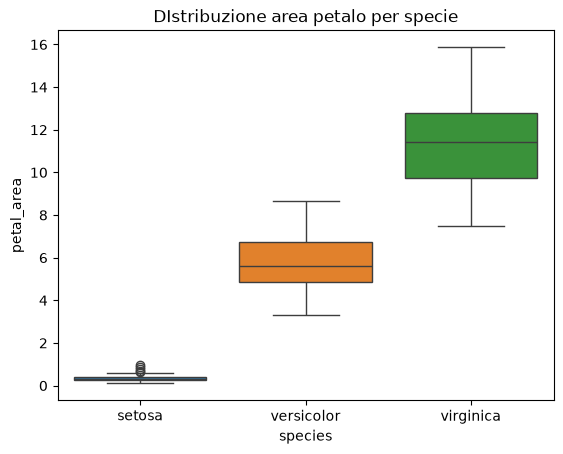

In [128]:
#Grafico della distribuzione dell'area del petalo per specie (boxplot)
sns.boxplot(data=df,y='petal_area',x='species',hue='species')
plt.title('DIstribuzione area petalo per specie')
plt.show